In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn






In [2]:
df =  pd.read_csv('../data/processed/youtube_cleaned.csv')
print(f'Shape: {df.shape}')
print("Type of Columns we've got to anaylze deeply:")
print(df.dtypes)
print("First few Rows are:")
df.head()

Shape: (55886, 19)
Type of Columns we've got to anaylze deeply:
index                      int64
video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_date              object
time_frame                object
published_day_of_week     object
publish_country           object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
category_name             object
dtype: object
First few Rows are:


,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,category_name
0,0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13,17:00 to 17:59,Monday,US,SHANtell martin,748374,30368,1061,4214,False,False,False,People & Blogs
1,1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",1080586,30368,1061,4214,False,False,False,Entertainment
2,2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",1080586,30368,1061,4214,False,False,False,Comedy
3,3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False,Entertainment
4,4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",1080586,30368,1061,4214,False,False,False,Entertainment


In [3]:
date_time_col = ['trending_date', 'publish_date']
for col in date_time_col:
    df[col] = pd.to_datetime(df[col],errors='coerce')

df.dtypes

index                              int64
video_id                          object
trending_date             datetime64[ns]
title                             object
channel_title                     object
category_id                        int64
publish_date              datetime64[ns]
time_frame                        object
published_day_of_week             object
publish_country                   object
tags                              object
views                              int64
likes                              int64
dislikes                           int64
comment_count                      int64
comments_disabled                   bool
ratings_disabled                    bool
video_error_or_removed              bool
category_name                     object
dtype: object

In [4]:
df.isnull().sum()

index                     0
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_date              0
time_frame                0
published_day_of_week     0
publish_country           0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
category_name             0
dtype: int64

In [5]:
df['is_published_weekend'] = df['published_day_of_week'].isin(['Saturday', 'Sunday']).astype(str)


In [6]:
df['trending_day_of_week'] = df['trending_date'].dt.day_name()
df['is_trending_weekend'] = df['trending_day_of_week'].isin(['Saturday', 'Sunday']).astype(str)

In [7]:
df['hour_of_trending'] = df['time_frame'].str.extract(r'(\d+):').astype(int)

In [8]:
df['days_until_trending'] = (df['trending_date'] - df['publish_date']).dt.days

In [9]:
df.to_csv('../data/features/youtube_features.csv', index=False)

In [10]:
df.head()

,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,...,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,category_name,is_published_weekend,trending_day_of_week,is_trending_weekend,hour_of_trending,days_until_trending
0,0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13,17:00 to 17:59,Monday,US,...,4214,False,False,False,People & Blogs,False,Tuesday,False,17,1
1,1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13,7:00 to 7:59,Monday,US,...,4214,False,False,False,Entertainment,False,Tuesday,False,7,1
2,2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12,19:00 to 19:59,Sunday,US,...,4214,False,False,False,Comedy,True,Tuesday,False,19,2
3,3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13,11:00 to 11:59,Monday,US,...,2146,False,False,False,Entertainment,False,Tuesday,False,11,1
4,4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12,18:00 to 18:59,Sunday,US,...,4214,False,False,False,Entertainment,True,Tuesday,False,18,2


In [11]:
print(f"📊 Summary for: days_until_trending")
display(df['days_until_trending'].describe())

📊 Summary for: days_until_trending


count    55886.000000
mean         7.104498
std        109.127266
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       4215.000000
Name: days_until_trending, dtype: float64

In [12]:
sn.set_theme(style="whitegrid",context='talk')
plt.rcParams.update({
    'font.size':12,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'figure.dpi': 150
})

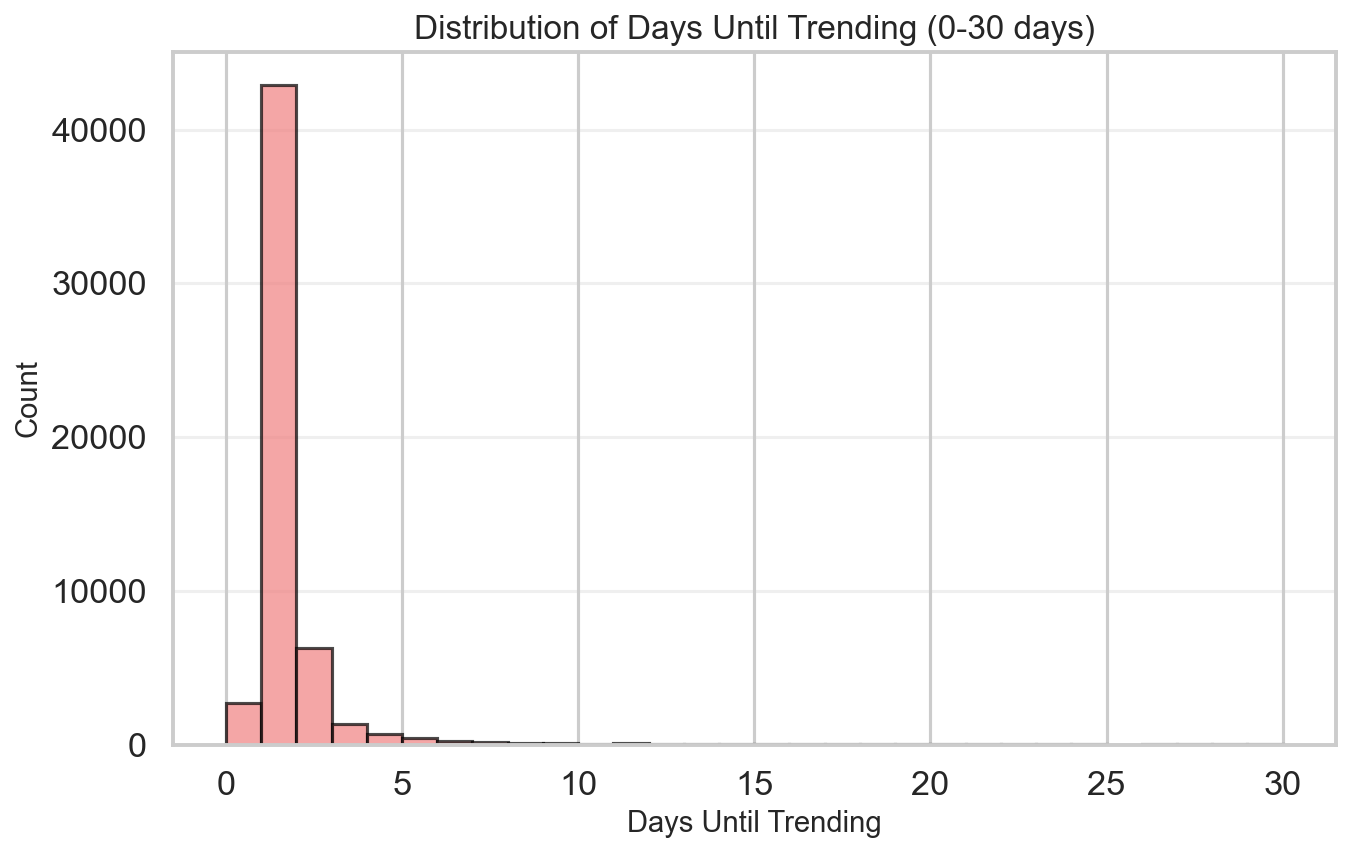


=== Average Day to Get Video Trending  ===
7.104498443259493
Day with highest number of videos to trend: 1 (count = 42937)


In [13]:
plt.figure(figsize=(10,6))
plt.hist(df['days_until_trending'], bins=30, range=(0,30),
         color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Days Until Trending (0-30 days)', fontsize=16)
plt.xlabel('Days Until Trending', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n=== Average Day to Get Video Trending  ===")
print(df['days_until_trending'].mean())
counts = df['days_until_trending'].value_counts()
most_common_day = counts.idxmax()
count = counts.max()
print(f"Day with highest number of videos to trend: {most_common_day} (count = {count})")




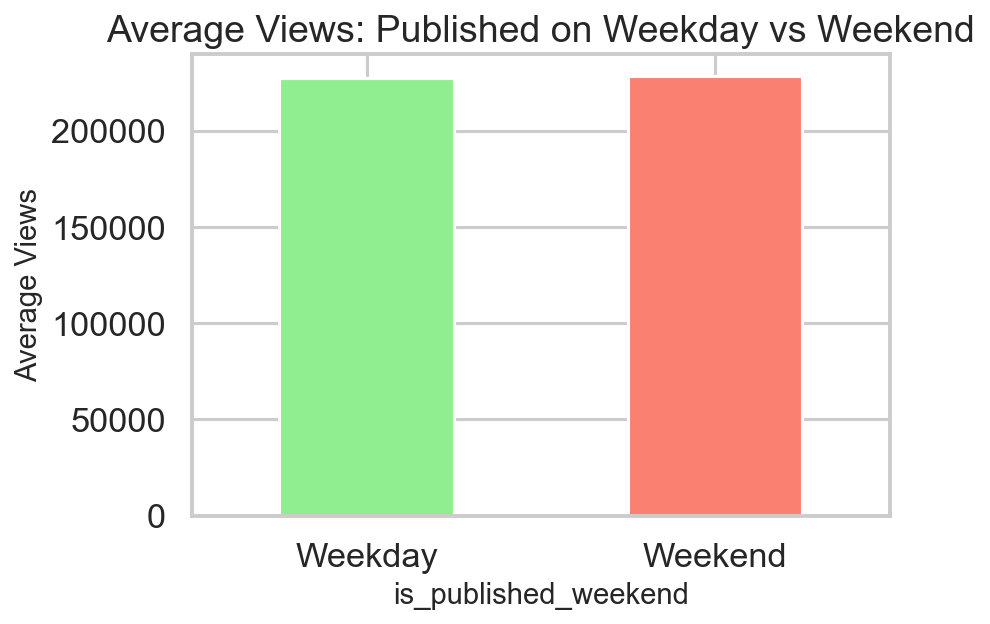

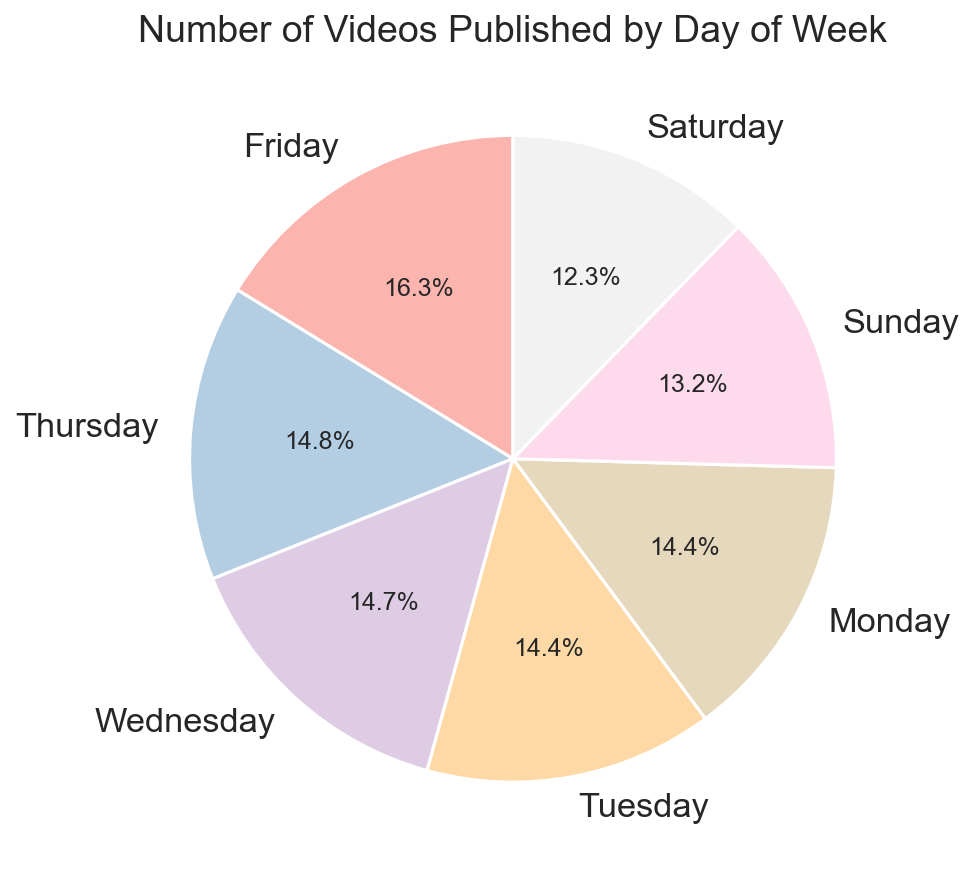

=== Published Video Summary ===
Number of videos by weekend/weekday:
is_published_weekend
False    41667
True     14219
Name: count, dtype: int64

Average views by weekend/weekday:
is_published_weekend
False    227424.569971
True     228506.349321
Name: views, dtype: float64

Number of videos by each day of week:
published_day_of_week
Friday       9082
Thursday     8272
Wednesday    8199
Tuesday      8060
Monday       8054
Sunday       7363
Saturday     6856
Name: count, dtype: int64


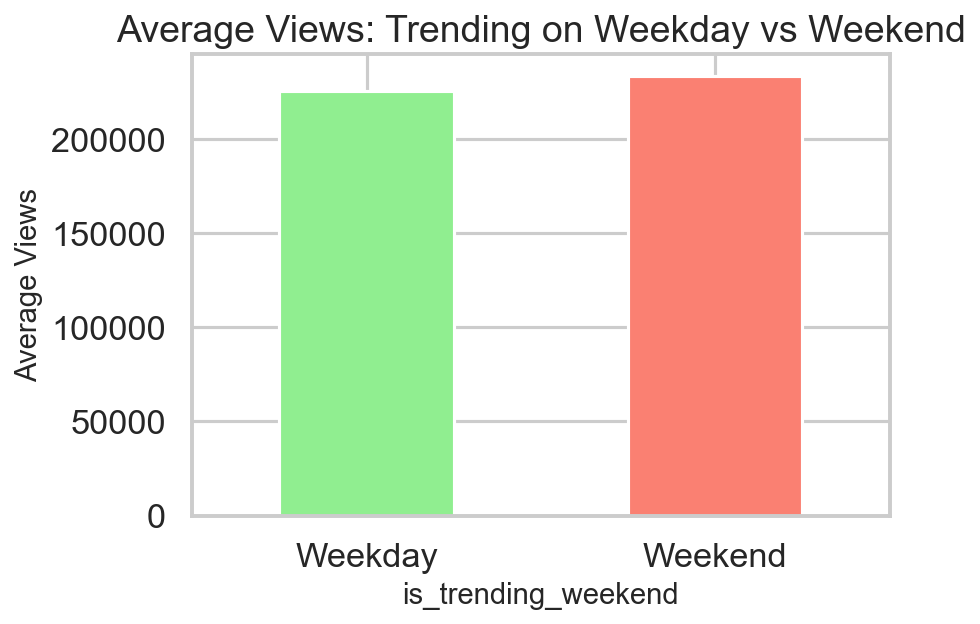

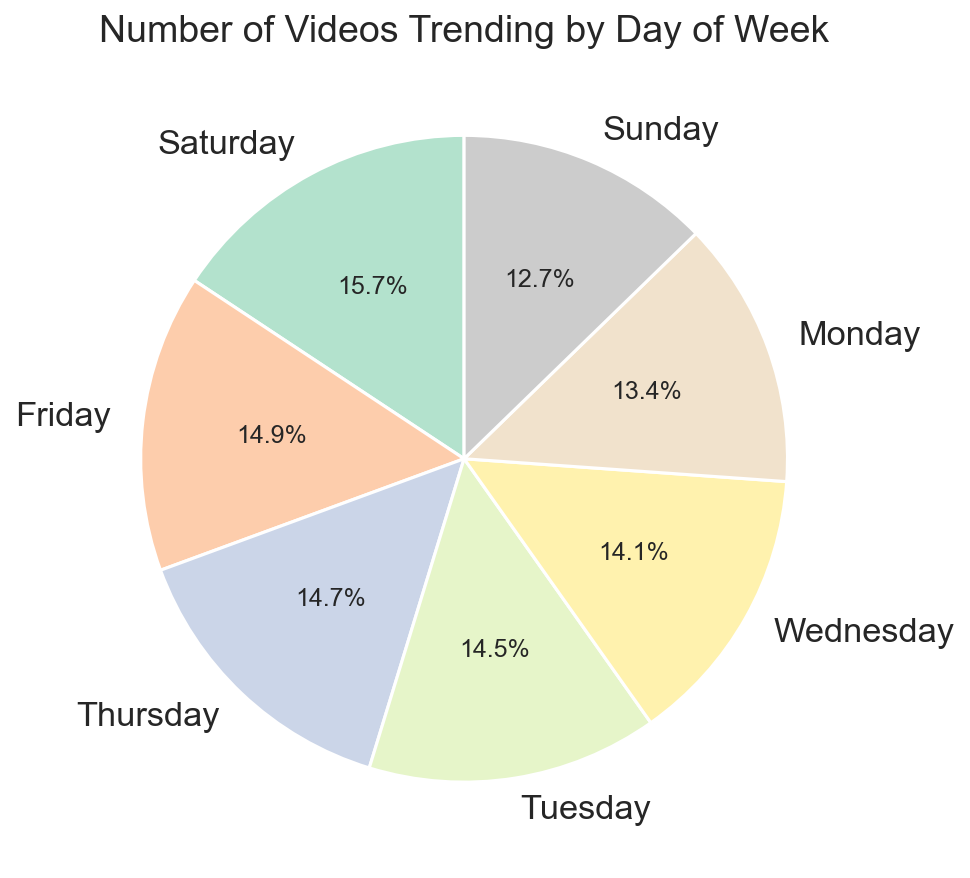

=== Trending Video Summary ===
Number of videos trending by weekend/weekday:
is_trending_weekend
False    39995
True     15891
Name: count, dtype: int64

Average views by weekend/weekday:
is_trending_weekend
False    225400.753569
True     233486.136744
Name: views, dtype: float64

Number of videos trending by each day of week:
trending_day_of_week
Saturday     8776
Friday       8326
Thursday     8194
Tuesday      8123
Wednesday    7866
Monday       7486
Sunday       7115
Name: count, dtype: int64


In [14]:
# Bar plot: average views by weekend vs weekday
plt.figure(figsize=(6,4))
df.groupby('is_published_weekend')['views'].mean().plot(kind='bar', color=['lightgreen','salmon'])
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.ylabel('Average Views')
plt.title('Average Views: Published on Weekday vs Weekend')
plt.show()

# Pie chart: number of videos by day of week
plt.figure(figsize=(7,7))
df['published_day_of_week'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.ylabel('')
plt.title('Number of Videos Published by Day of Week')
plt.show()

# Summary report
print("=== Published Video Summary ===")
print("Number of videos by weekend/weekday:")
print(df['is_published_weekend'].value_counts())
print("\nAverage views by weekend/weekday:")
print(df.groupby('is_published_weekend')['views'].mean())
print("\nNumber of videos by each day of week:")
print(df['published_day_of_week'].value_counts())

# -------------------------
# TRENDING VIDEO ANALYSIS
# -------------------------
# Bar plot: average views by weekend vs weekday
plt.figure(figsize=(6,4))
df.groupby('is_trending_weekend')['views'].mean().plot(kind='bar', color=['lightgreen','salmon'])
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.ylabel('Average Views')
plt.title('Average Views: Trending on Weekday vs Weekend')
plt.show()

# Pie chart: number of trending videos by day of week
plt.figure(figsize=(7,7))
df['trending_day_of_week'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Pastel2')
plt.ylabel('')
plt.title('Number of Videos Trending by Day of Week')
plt.show()

# Summary report
print("=== Trending Video Summary ===")
print("Number of videos trending by weekend/weekday:")
print(df['is_trending_weekend'].value_counts())
print("\nAverage views by weekend/weekday:")
print(df.groupby('is_trending_weekend')['views'].mean())
print("\nNumber of videos trending by each day of week:")
print(df['trending_day_of_week'].value_counts())

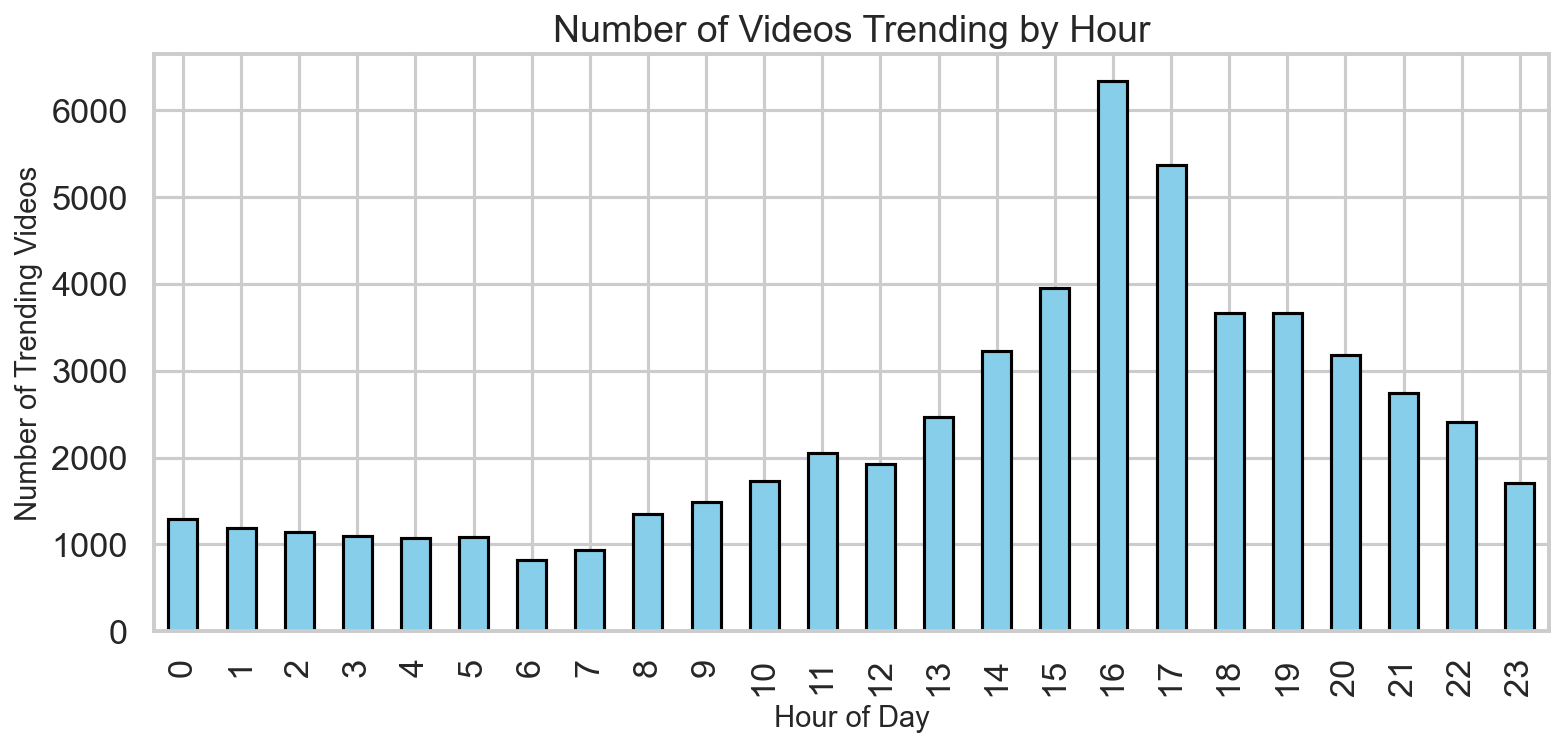


=== Top hour by maximum number of trending video  ===
hour_of_trending
16    6330
17    5362
15    3947
18    3667
19    3665
14    3229
20    3176
21    2742
13    2471
22    2404
11    2058
12    1926
10    1726
23    1702
9     1491
8     1353
0     1288
1     1194
2     1138
3     1093
5     1087
4     1073
7      942
6      822
Name: count, dtype: int64


In [15]:
hour_counts = df['hour_of_trending'].value_counts().sort_index()

plt.figure(figsize=(12,5))
hour_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xticks(range(24), [str(h) for h in range(24)])
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trending Videos')
plt.title('Number of Videos Trending by Hour')
plt.show()

print("\n=== Top hour by maximum number of trending video  ===")
print(hour_counts.sort_values(ascending=False))